# Prediccion de churn para Beta Bank
Resumen ejecutivo para riesgo de churn y priorizacion de retencion.

## Resumen ejecutivo
- Mejor modelo: Random Forest con class_weight (200 arboles, max_depth=10).
- Rendimiento en test: F1 = 0.629, AUC-ROC = 0.863 (cumple el objetivo).
- Impacto: ordenar clientes por riesgo de churn para priorizar acciones de retencion.

## Contexto de negocio y criterio de exito
- El churn sube y retener es mas barato que adquirir clientes.
- Objetivo: F1 >= 0.59 en el set de test.
- Reportar AUC-ROC para medir la calidad del ranking de riesgo.

In [13]:
import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

import matplotlib.pyplot as plt

RANDOM_STATE = 12345

In [14]:
data_path = Path("../data/Churn.csv")
df = pd.read_csv(data_path)
target_col = "Exited"

df.head(3)
df.shape

(10000, 14)

## Resumen de datos
El dataset tiene 10,000 filas y 14 columnas. La tasa de churn es 20.37% (1 de cada 5 clientes).
Los faltantes se concentran en Tenure (~9.1%) y no hay filas duplicadas.
Desde negocio, esto sugiere un impacto financiero relevante y justifica priorizar retencion.

In [ ]:
missing_share = df.isna().mean().sort_values(ascending=False)
missing_columns = missing_share[missing_share > 0]

data_overview = pd.DataFrame(
    {
        "filas": [len(df)],
        "columnas": [df.shape[1]],
        "tasa_churn": [df[target_col].mean()],
        "valores_faltantes": [df.isna().sum().sum()],
        "filas_duplicadas": [df.duplicated().sum()],
    }
)
display(data_overview)

display(missing_columns.head(10))

,rows,columns,churn_rate,missing_values,duplicate_rows
0,10000,14,0.2037,909,0


Tenure    0.0909
dtype: float64

,count,share
Exited,,
0,7963,0.7963
1,2037,0.2037


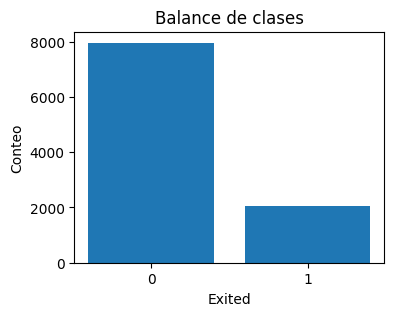

In [ ]:
class_counts = df[target_col].value_counts()
class_share = df[target_col].value_counts(normalize=True)

class_balance = pd.DataFrame({"conteo": class_counts, "proporcion": class_share})
display(class_balance)

plt.figure(figsize=(4, 3))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Balance de clases")
plt.xlabel("Cliente sale (0 = no, 1 = si)")
plt.ylabel("Conteo")
plt.show()

## Analisis de balance de clases
El churn es ~20% (2037 de 10,000), por lo que hay riesgo de subestimar clientes en salida.
Desde negocio, el modelo debe recuperar mas churners aun si aumenta falsos positivos.

## Preparacion y division de datos
- Eliminar identificadores (RowNumber, CustomerId, Surname).
- Imputar faltantes (mediana en numericas, mas_frecuente en categoricas).
- Codificar Geography y Gender con one-hot.
- Dividir en train/valid/test con estratificacion (80/10/10).

In [ ]:
drop_cols = ["RowNumber", "CustomerId", "Surname"]
X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
 )
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
 )

categorical_cols = ["Geography", "Gender"]
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

def make_pipeline(model):
    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

def evaluate_model(pipe, X_tr, y_tr, X_val, y_val, label):
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_val)
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_proba)
    else:
        roc_auc = np.nan
    f1 = f1_score(y_val, y_pred)
    return {"label": label, "f1": f1, "roc_auc": roc_auc}

def build_model(model_key, params):
    if model_key == "logreg":
        base = {"max_iter": 1000, "solver": "liblinear"}
        base.update(params)
        return LogisticRegression(**base)
    if model_key == "rf":
        base = {
            "n_estimators": 200,
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
        base.update(params)
        return RandomForestClassifier(**base)
    raise ValueError(f"Unknown model_key: {model_key}")

results = []

def add_result(label, approach, model_key, params, metrics):
    results.append(
        {
            "label": label,
            "approach": approach,
            "model": model_key,
            "params": params,
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
        }
    )

def evaluate_and_store(model_key, approach, params, label, X_tr=None, y_tr=None):
    if X_tr is None:
        X_tr, y_tr = X_train, y_train
    model = build_model(model_key, params)
    pipe = make_pipeline(model)
    metrics = evaluate_model(pipe, X_tr, y_tr, X_valid, y_valid, label)
    add_result(label, approach, model_key, params, metrics)

split_sizes = pd.DataFrame(
    {
        "conjunto": ["entrenamiento", "validacion", "prueba"],
        "filas": [len(X_train), len(X_valid), len(X_test)],
        "tasa_churn": [y_train.mean(), y_valid.mean(), y_test.mean()],
    }
)
split_sizes

,set,rows,churn_rate
0,train,8000,0.20375
1,valid,1000,0.20400
2,test,1000,0.20300


## Modelos base (sin manejo de desbalance)
Comparamos Logistic Regression y Random Forest como referencia inicial.

In [18]:
evaluate_and_store("logreg", "baseline", {}, "logreg_base")
evaluate_and_store("rf", "baseline", {}, "rf_base")

baseline_df = (
    pd.DataFrame(results)
    .query("approach == 'baseline'")
    .sort_values("f1", ascending=False)
)
baseline_df

,label,approach,model,params,f1,roc_auc
1,rf_base,baseline,rf,{},0.582583,0.867992
0,logreg_base,baseline,logreg,{},0.084388,0.670953


## Analisis de resultados base
Random Forest base alcanza F1 = 0.583 (AUC-ROC = 0.868), aun por debajo del umbral.
En negocio, esto implica perder parte de los clientes en riesgo si no ajustamos el desbalance.
Logistic Regression no captura bien la senal (F1 = 0.084), por lo que no es competitivo.

## Estrategias para desbalance
- class_weight para penalizar errores en la clase minoritaria.
- Upsampling de la clase minoritaria en entrenamiento.

In [19]:
for C in [0.1, 1.0, 10.0]:
    params = {"class_weight": "balanced", "C": C}
    label = f"logreg_bal_C{C}"
    evaluate_and_store("logreg", "class_weight", params, label)

for n_estimators in [200, 400]:
    for max_depth in [None, 10, 20]:
        params = {
            "class_weight": "balanced",
            "n_estimators": n_estimators,
            "max_depth": max_depth,
        }
        label = f"rf_bal_ne{n_estimators}_md{max_depth}"
        evaluate_and_store("rf", "class_weight", params, label)

class_weight_df = (
    pd.DataFrame(results)
    .query("approach == 'class_weight'")
    .sort_values("f1", ascending=False)
)
class_weight_df.head(10)

,label,approach,model,params,f1,roc_auc
6,rf_bal_ne200_md10,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 2...",0.658768,0.868602
9,rf_bal_ne400_md10,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 4...",0.657277,0.869205
7,rf_bal_ne200_md20,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 2...",0.560000,0.868186
8,rf_bal_ne400_mdNone,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 4...",0.552795,0.865288
10,rf_bal_ne400_md20,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 4...",0.552147,0.866397
5,rf_bal_ne200_mdNone,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 2...",0.550459,0.861455
2,logreg_bal_C0.1,class_weight,logreg,"{'class_weight': 'balanced', 'C': 0.1}",0.475712,0.743232
4,logreg_bal_C10.0,class_weight,logreg,"{'class_weight': 'balanced', 'C': 10.0}",0.475083,0.774584
3,logreg_bal_C1.0,class_weight,logreg,"{'class_weight': 'balanced', 'C': 1.0}",0.474916,0.743183


## Analisis de class_weight
El mejor modelo sube a F1 = 0.659 con Random Forest (200 arboles, max_depth=10).
Esto aumenta la deteccion de churners sin degradar el ranking (AUC-ROC alto).

In [20]:
def upsample_minority(X_data, y_data, random_state=RANDOM_STATE):
    data = X_data.copy()
    data["_target"] = y_data.values
    counts = data["_target"].value_counts()
    minority_class = counts.idxmin()
    majority_class = counts.idxmax()

    minority = data[data["_target"] == minority_class]
    majority = data[data["_target"] == majority_class]

    minority_upsampled = resample(
        minority,
        replace=True,
        n_samples=len(majority),
        random_state=random_state,
    )

    upsampled = pd.concat([majority, minority_upsampled], axis=0)
    upsampled = upsampled.sample(frac=1, random_state=random_state).reset_index(drop=True)
    y_up = upsampled.pop("_target")
    return upsampled, y_up

X_train_up, y_train_up = upsample_minority(X_train, y_train)

evaluate_and_store("logreg", "upsample", {}, "logreg_up", X_tr=X_train_up, y_tr=y_train_up)
evaluate_and_store("rf", "upsample", {}, "rf_up", X_tr=X_train_up, y_tr=y_train_up)

upsample_df = (
    pd.DataFrame(results)
    .query("approach == 'upsample'")
    .sort_values("f1", ascending=False)
)
upsample_df

,label,approach,model,params,f1,roc_auc
12,rf_up,upsample,rf,{},0.631016,0.856119
11,logreg_up,upsample,logreg,{},0.461028,0.725441


## Analisis de upsampling
Upsampling mejora el baseline (F1 = 0.631), pero queda debajo de class_weight.
Desde negocio, class_weight ofrece mejor balance entre recall y falsos positivos.

In [21]:
results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc"], ascending=False)
display(results_df.reset_index(drop=True).head(10))

best_row = results_df.iloc[0]
best_row

,label,approach,model,params,f1,roc_auc
0,rf_bal_ne200_md10,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 2...",0.658768,0.868602
1,rf_bal_ne400_md10,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 4...",0.657277,0.869205
2,rf_up,upsample,rf,{},0.631016,0.856119
3,rf_base,baseline,rf,{},0.582583,0.867992
4,rf_bal_ne200_md20,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 2...",0.560000,0.868186
5,rf_bal_ne400_mdNone,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 4...",0.552795,0.865288
6,rf_bal_ne400_md20,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 4...",0.552147,0.866397
7,rf_bal_ne200_mdNone,class_weight,rf,"{'class_weight': 'balanced', 'n_estimators': 2...",0.550459,0.861455
8,logreg_bal_C0.1,class_weight,logreg,"{'class_weight': 'balanced', 'C': 0.1}",0.475712,0.743232
9,logreg_bal_C10.0,class_weight,logreg,"{'class_weight': 'balanced', 'C': 10.0}",0.475083,0.774584


label                                       rf_bal_ne200_md10
approach                                         class_weight
model                                                      rf
params      {'class_weight': 'balanced', 'n_estimators': 2...
f1                                                   0.658768
roc_auc                                              0.868602
Name: 6, dtype: object

## Seleccion de modelo y prueba final
Se elige Random Forest con class_weight (200 arboles, max_depth=10) por F1 en validacion.
En test, F1 = 0.629 y AUC-ROC = 0.863, confirmando generalizacion.

,metric,value
0,F1,0.628571
1,AUC-ROC,0.862662


,Pred 0,Pred 1
Actual 0,712,85
Actual 1,71,132


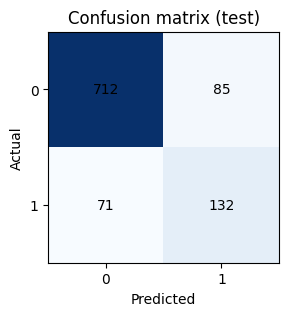

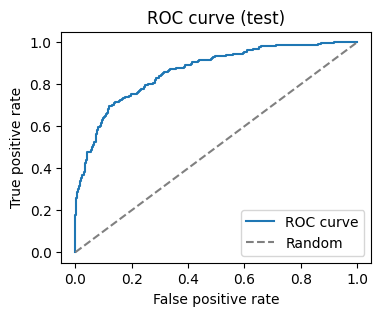

In [ ]:
X_full = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)

if best_row["approach"] == "upsample":
    X_full, y_full = upsample_minority(X_full, y_full)

best_model = build_model(best_row["model"], best_row["params"])
best_pipe = make_pipeline(best_model)
best_pipe.fit(X_full, y_full)

y_test_pred = best_pipe.predict(X_test)
y_test_proba = best_pipe.predict_proba(X_test)[:, 1]

f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

test_summary = pd.DataFrame(
    {"metrica": ["F1", "AUC-ROC"], "valor": [f1_test, roc_auc_test]}
)
display(test_summary)

conf_mat = confusion_matrix(y_test, y_test_pred)
conf_mat_df = pd.DataFrame(
    conf_mat,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"],
)
display(conf_mat_df)

plt.figure(figsize=(4, 3))
plt.imshow(conf_mat, cmap="Blues")
plt.title("Matriz de confusion (test)")
plt.xlabel("Predicho")
plt.ylabel("Real")
for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        plt.text(j, i, conf_mat[i, j], ha="center", va="center", color="black")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label="Curva ROC")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.title("Curva ROC (test)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc="lower right")
plt.show()

## Conclusiones
- El modelo cumple el objetivo con F1 = 0.629 y AUC-ROC = 0.863 en test.
- Matriz de confusion: 132 churners detectados, 71 perdidos, 85 falsos positivos.
- Recomendacion: usar el score para priorizar retencion en clientes de mayor riesgo.
- Siguiente paso: ajustar el umbral segun costo de retencion vs perdida.